<a href="https://colab.research.google.com/github/JTempletoni/Uk-Energy-Modelling/blob/main/01_data_acquisition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Data Acquisition

**What this notebook does**: pulls half-hourly GB electricity market data from two free,
no-auth-required APIs and saves clean parquet files for use in all downstream notebooks.

**Inputs**: none (API calls only)

**Outputs**:
- `data/elexon_system_prices.parquet` — half-hourly system buy/sell prices (imbalance prices)
- `data/elexon_generation.parquet`   — half-hourly generation by fuel type
- `data/carbon_intensity.parquet`    — half-hourly regional generation mix including Scotland

---

## Market context

GB electricity settles in 48 half-hourly periods per day. The **System Buy Price (SBP)** and
**System Sell Price (SSP)** are the imbalance prices — what generators/suppliers pay or receive
if they are short or long relative to their contracted position. These prices are:

- **Highly volatile**: spikes of 10x the average are common during wind droughts + cold snaps
- **Occasionally negative**: when Scottish wind exceeds B6 transfer capacity and must be curtailed,
  prices can go deeply negative (down to −£6000/MWh in extreme cases)
- **Strongly seasonal**: winter demand peaks, summer wind troughs, weekday/weekend patterns
- **Mean-reverting**: unlike equities, electricity prices revert to marginal cost of generation

These properties make electricity prices structurally different from equity returns and
are exactly the stylized facts our generative model needs to reproduce.

**Data sources used here**:
- [Elexon Insights API](https://developer.data.elexon.co.uk/) — official GB balancing mechanism data, free, no API key needed
- [Carbon Intensity API](https://api.carbonintensity.org.uk/) — National Grid ESO data, free, no auth


In [50]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DATA_DIR = Path("/content/drive/MyDrive/energy_synthetic_data/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
# ── Install / upgrade dependencies ────────────────────────────────────────────
# Run once per Colab session. Skip if running locally with requirements.txt installed.
%pip install -q requests pandas pyarrow tqdm elexonpy

In [52]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import time
import datetime
from pathlib import Path

import requests
import pandas as pd
from tqdm.notebook import tqdm

# ── Output directory ──────────────────────────────────────────────────────────
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print(f"Data will be saved to: {DATA_DIR.resolve()}")

Data will be saved to: /content/data


---
## Part 1 — Elexon Insights API

The new Elexon Insights API (replaced the old BMRS in May 2024) is fully open — no API key
required for most endpoints. Documentation: https://developer.data.elexon.co.uk/

We pull two datasets:
1. **System prices** (`/balancing/settlement/system-prices`) — SBP and SSP per settlement period
2. **Generation by fuel type** (`/generation/outturn/summary`) — half-hourly MW by technology


In [ ]:
# ── Date range configuration ──────────────────────────────────────────────────
# Start from 2021-01-01 to capture:
#   - The post-COVID demand recovery
#   - The 2021-2022 energy crisis (extreme price spikes)
#   - High-wind / negative price episodes from Scottish wind growth
#
# Adjust START_DATE / END_DATE to taste. More data = better generative model.
# Note: ~3 years of half-hourly data = ~52,000 rows — manageable.

START_DATE = datetime.date(2021, 1, 1)
END_DATE   = datetime.date(2024, 12, 31)

def date_range_chunks(start: datetime.date, end: datetime.date,
                       chunk_days: int = 7):
    """Yield (from_date, to_date) tuples in chunks.

    The Elexon API has a max window per request (~7 days for most endpoints).
    """
    current = start
    while current <= end:
        chunk_end = min(current + datetime.timedelta(days=chunk_days - 1), end)
        yield current, chunk_end
        current = chunk_end + datetime.timedelta(days=1)

chunks = list(date_range_chunks(START_DATE, END_DATE, chunk_days=7))
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Chunks: {len(chunks)} weekly batches")

Date range: 2021-01-01 to 2024-12-31
Chunks: 209 weekly batches


In [ ]:
# ── 1a. System prices (imbalance prices: SBP and SSP) ─────────────────────────
#
# Endpoint: GET /balancing/settlement/system-prices/{settlementDate}
# Returns: SBP, SSP, netImbalanceVolume per settlement period
#
# SBP = System Buy Price: what a party short of their position pays
# SSP = System Sell Price: what a party long of their position receives
# In practice SBP ≈ SSP ≈ 'the imbalance price' most of the time

# Initialise elexonpy clients
from elexonpy.api_client import ApiClient
from elexonpy.api.indicative_imbalance_settlement_api import IndicativeImbalanceSettlementApi
from elexonpy.api.generation_api import GenerationApi

api_client    = ApiClient()
settlement_api = IndicativeImbalanceSettlementApi(api_client)
generation_api = GenerationApi(api_client)



In [ ]:
# Fetch system prices — one day at a time (API requires date in path)
all_dates = [
    START_DATE + datetime.timedelta(days=i)
    for i in range((END_DATE - START_DATE).days + 1)
]

system_price_records = []

for d in tqdm(all_dates, desc="Fetching system prices"):
    try:
        response = settlement_api.balancing_settlement_system_prices_settlement_date_get(
            settlement_date=d.isoformat(),
            format="json"
        )
        for row in response.data:
            system_price_records.append(row.to_dict())
        time.sleep(0.05)
    except Exception as e:
        print(f"Error on {d}: {e}")
        time.sleep(2)

print(f"\nFetched {len(system_price_records):,} system price records")

Fetching system prices:   0%|          | 0/1461 [00:00<?, ?it/s]


Fetched 70,117 system price records


In [53]:
# ── Clean and structure system prices ─────────────────────────────────────────

df_prices = pd.DataFrame(system_price_records)
print("Raw columns:", df_prices.columns.tolist())
print(df_prices.head(3))

Raw columns: ['settlement_date', 'settlement_period', 'start_time', 'created_date_time', 'system_sell_price', 'system_buy_price', 'bsad_defaulted', 'price_derivation_code', 'reserve_scarcity_price', 'net_imbalance_volume', 'sell_price_adjustment', 'buy_price_adjustment', 'replacement_price', 'replacement_price_reference_volume', 'total_accepted_offer_volume', 'total_accepted_bid_volume', 'total_adjustment_sell_volume', 'total_adjustment_buy_volume', 'total_system_tagged_accepted_offer_volume', 'total_system_tagged_accepted_bid_volume', 'total_system_tagged_adjustment_sell_volume', 'total_system_tagged_adjustment_buy_volume']
  settlement_date  settlement_period                start_time  \
0      2021-01-01                  1 2021-01-01 00:00:00+00:00   
1      2021-01-01                  2 2021-01-01 00:30:00+00:00   
2      2021-01-01                  3 2021-01-01 01:00:00+00:00   

          created_date_time  system_sell_price  system_buy_price  \
0 2021-01-01 00:52:15+00:00       

In [54]:
# ── Clean and structure system prices ─────────────────────────────────────────

df_prices = pd.DataFrame(system_price_records)

# Show what columns actually came back from the API
print("Actual columns:", df_prices.columns.tolist())

# Rename to short snake_case names
# elexonpy to_dict() returns snake_case already, so we map from those
col_map = {
    "system_buy_price":    "sbp",
    "system_sell_price":   "ssp",
    "net_imbalance_volume": "net_imbalance_volume",
}
df_prices = df_prices.rename(columns={k: v for k, v in col_map.items() if k in df_prices.columns})

# Parse datetimes
if "settlement_date" in df_prices.columns:
    df_prices["settlement_date"] = pd.to_datetime(df_prices["settlement_date"]).dt.date

if "start_time" in df_prices.columns:
    df_prices["start_time"] = pd.to_datetime(df_prices["start_time"], utc=True)
else:
    # Reconstruct from settlement_date + settlement_period if start_time missing
    df_prices["start_time"] = (
        pd.to_datetime(df_prices["settlement_date"])
        + pd.to_timedelta((df_prices["settlement_period"] - 1) * 30, unit="min")
        - pd.Timedelta("1 hour")
    )

# Sort and drop duplicates
df_prices = (
    df_prices
    .sort_values("start_time")
    .drop_duplicates(subset="start_time")
    .reset_index(drop=True)
)

# Numeric coercion
for col in ["sbp", "ssp", "net_imbalance_volume"]:
    if col in df_prices.columns:
        df_prices[col] = pd.to_numeric(df_prices[col], errors="coerce")

# Midpoint price — our primary price series
df_prices["mid_price"] = (df_prices["sbp"] + df_prices["ssp"]) / 2

print(f"System prices: {len(df_prices):,} rows")
print(f"Date range: {df_prices['start_time'].min()} → {df_prices['start_time'].max()}")
print(f"Price range: £{df_prices['mid_price'].min():.1f} to £{df_prices['mid_price'].max():.1f}/MWh")
print(f"Negative prices: {(df_prices['mid_price'] < 0).sum():,} periods ({(df_prices['mid_price'] < 0).mean()*100:.1f}%)")
print("\nSample:")
df_prices[["start_time", "sbp", "ssp", "mid_price", "net_imbalance_volume"]].head()

Actual columns: ['settlement_date', 'settlement_period', 'start_time', 'created_date_time', 'system_sell_price', 'system_buy_price', 'bsad_defaulted', 'price_derivation_code', 'reserve_scarcity_price', 'net_imbalance_volume', 'sell_price_adjustment', 'buy_price_adjustment', 'replacement_price', 'replacement_price_reference_volume', 'total_accepted_offer_volume', 'total_accepted_bid_volume', 'total_adjustment_sell_volume', 'total_adjustment_buy_volume', 'total_system_tagged_accepted_offer_volume', 'total_system_tagged_accepted_bid_volume', 'total_system_tagged_adjustment_sell_volume', 'total_system_tagged_adjustment_buy_volume']
System prices: 70,117 rows
Date range: 2021-01-01 00:00:00+00:00 → 2024-12-31 23:30:00+00:00
Price range: £-185.3 to £4037.8/MWh
Negative prices: 2,386 periods (3.4%)

Sample:


,start_time,sbp,ssp,mid_price,net_imbalance_volume
0,2021-01-01 00:00:00+00:00,73.15,73.15,73.15,843.6931
1,2021-01-01 00:30:00+00:00,73.15,73.15,73.15,934.5820
2,2021-01-01 01:00:00+00:00,72.00,72.00,72.00,604.7328
3,2021-01-01 01:30:00+00:00,71.90,71.90,71.90,307.3387
4,2021-01-01 02:00:00+00:00,71.50,71.50,71.50,48.8845


In [55]:
# ── Save system prices ────────────────────────────────────────────────────────
out_path = DATA_DIR / "elexon_system_prices.parquet"
df_prices.to_parquet(out_path, index=False)
print(f"Saved: {out_path}  ({out_path.stat().st_size / 1e3:.1f} KB)")

Saved: data/elexon_system_prices.parquet  (5590.7 KB)


In [ ]:
# ── 1b. Generation outturn by fuel type ───────────────────────────────────────
#
# Endpoint: GET /generation/outturn/summary
# Returns: half-hourly MW generation by fuel type (WIND, GAS, NUCLEAR, COAL, SOLAR, etc.)
#
# Why we want this:
#   - Wind generation is the primary driver of price volatility in GB
#   - Gas generation is the marginal unit setting the price most of the time
#   - Nuclear is baseload (constant) — useful as a normalisation reference
#   - Solar has strong seasonal / diurnal patterns useful for conditioning

generation_records = []

for from_d, to_d in tqdm(list(date_range_chunks(START_DATE, END_DATE)),
                          desc="Fetching generation"):
    try:
        response = generation_api.generation_outturn_summary_get(
            start_time=datetime.datetime.combine(from_d, datetime.time()),
            end_time=datetime.datetime.combine(to_d, datetime.time(23, 30)),
            format="json"
        )
        for row in response:
            generation_records.append(row.to_dict())
        time.sleep(0.2)
    except Exception as e:
        print(f"Error on {from_d}: {e}")
        time.sleep(2)

print(f"\nFetched {len(generation_records):,} generation records")

Fetching generation:   0%|          | 0/209 [00:00<?, ?it/s]


Fetched 69,885 generation records


In [56]:
# ── Clean generation data ─────────────────────────────────────────────────────

df_gen_raw = pd.DataFrame(generation_records)
print("Raw columns:", df_gen_raw.columns.tolist())
print(df_gen_raw.head(3))

Raw columns: ['start_time', 'settlement_period', 'data']
                 start_time  settlement_period  \
0 2021-01-01 00:00:00+00:00                  1   
1 2021-01-01 00:30:00+00:00                  2   
2 2021-01-01 01:00:00+00:00                  3   

                                                data  
0  [{'fuel_type': 'BIOMASS', 'generation': 3116},...  
1  [{'fuel_type': 'BIOMASS', 'generation': 3115},...  
2  [{'fuel_type': 'BIOMASS', 'generation': 3105},...  


In [57]:
df_gen_raw = pd.DataFrame(generation_records)

# 'data' column contains a list of {fuel_type, generation} dicts
# We need to explode it into one row per fuel type
df_gen_exploded = df_gen_raw.explode("data").reset_index(drop=True)

# Extract fuel_type and generation from the dict in each row
df_gen_exploded["fuel_type"]     = df_gen_exploded["data"].apply(lambda x: x["fuel_type"])
df_gen_exploded["generation_mw"] = df_gen_exploded["data"].apply(lambda x: x["generation"])

# Parse datetime
df_gen_exploded["start_time"] = pd.to_datetime(df_gen_exploded["start_time"], utc=True)
df_gen_exploded["generation_mw"] = pd.to_numeric(df_gen_exploded["generation_mw"], errors="coerce")

# Pivot: rows = timestamps, columns = fuel types
df_gen = (
    df_gen_exploded
    .pivot_table(
        index="start_time",
        columns="fuel_type",
        values="generation_mw",
        aggfunc="mean"
    )
    .reset_index()
)

df_gen.columns = [c.lower().replace(" ", "_") for c in df_gen.columns]
df_gen = df_gen.sort_values("start_time").reset_index(drop=True)

print(f"Generation data: {len(df_gen):,} timestamps")
print(f"Fuel types: {[c for c in df_gen.columns if c != 'start_time']}")
df_gen.head()

Generation data: 69,885 timestamps
Fuel types: ['biomass', 'ccgt', 'coal', 'intele', 'intelec', 'intew', 'intfr', 'intgrnl', 'intifa2', 'intirl', 'intned', 'intnem', 'intnsl', 'intvkl', 'npshyd', 'nuclear', 'ocgt', 'oil', 'other', 'ps', 'wind']


,start_time,biomass,ccgt,coal,intele,intelec,intew,intfr,intgrnl,intifa2,...,intnem,intnsl,intvkl,npshyd,nuclear,ocgt,oil,other,ps,wind
0,2021-01-01 00:00:00+00:00,3116.0,11338.0,0.0,NaN,NaN,204.0,2004.0,NaN,0.0,...,1000.0,NaN,NaN,383.0,5955.0,0.0,0.0,192.0,NaN,4489.0
1,2021-01-01 00:30:00+00:00,3115.0,11497.0,0.0,NaN,NaN,204.0,2004.0,NaN,0.0,...,1000.0,NaN,NaN,379.0,5951.0,0.0,0.0,184.0,NaN,4351.0
2,2021-01-01 01:00:00+00:00,3105.0,10863.0,0.0,NaN,NaN,204.0,2004.0,NaN,0.0,...,1000.0,NaN,NaN,349.0,5947.0,0.0,0.0,191.0,NaN,4258.0
3,2021-01-01 01:30:00+00:00,3114.0,10248.0,0.0,NaN,NaN,204.0,2004.0,NaN,0.0,...,1000.0,NaN,NaN,334.0,5951.0,0.0,0.0,186.0,NaN,4265.0
4,2021-01-01 02:00:00+00:00,3116.0,9656.0,0.0,NaN,NaN,204.0,2004.0,NaN,0.0,...,1000.0,NaN,NaN,328.0,5951.0,0.0,0.0,185.0,NaN,4365.0


In [58]:
# Add useful derived columns
wind_cols = [c for c in df_gen.columns if "wind" in c]
if wind_cols:
    df_gen["total_wind_mw"] = df_gen[wind_cols].sum(axis=1)
    print(f"Wind columns summed: {wind_cols}")

renewable_cols = [c for c in df_gen.columns if any(x in c for x in ["wind", "solar", "hydro", "biomass"])]
if renewable_cols:
    df_gen["total_renewable_mw"] = df_gen[renewable_cols].sum(axis=1)

# Total system generation
gen_cols = [c for c in df_gen.columns if c != "start_time"]
df_gen["total_generation_mw"] = df_gen[gen_cols].clip(lower=0).sum(axis=1)

# Renewable penetration fraction
if "total_renewable_mw" in df_gen.columns:
    df_gen["renewable_fraction"] = df_gen["total_renewable_mw"] / df_gen["total_generation_mw"].replace(0, float("nan"))

# Save
out_path = DATA_DIR / "elexon_generation.parquet"
df_gen.to_parquet(out_path, index=False)
print(f"\nSaved: {out_path}  ({out_path.stat().st_size / 1e3:.1f} KB)")

Wind columns summed: ['wind']

Saved: data/elexon_generation.parquet  (3507.9 KB)


---
## Part 2 — Carbon Intensity API

National Grid ESO's Carbon Intensity API provides regional generation mix data
at half-hourly frequency. Critically it includes **Scotland as a separate region**,
which is exactly what we need to model the B6 constraint and wind curtailment dynamics.

No registration or API key required. Documentation: https://api.carbonintensity.org.uk/

Regions available: North Scotland, South Scotland, North West England, North East England,
Yorkshire, North Wales, South Wales, West Midlands, East Midlands, East England,
South West England, South England, London, South East England.


In [ ]:
# ── Carbon Intensity API helpers ──────────────────────────────────────────────

CI_BASE = "https://api.carbonintensity.org.uk"
CI_HEADERS = {"Accept": "application/json"}

# Scottish region IDs in the Carbon Intensity API
# 17 = North Scotland, 18 = South Scotland
SCOTLAND_REGIONS = {17: "north_scotland", 18: "south_scotland"}
# GB national = no region ID needed

def ci_get_regional(from_dt: datetime.datetime, to_dt: datetime.datetime,
                    region_id: int) -> list:
    """Fetch half-hourly regional generation mix from Carbon Intensity API."""
    from_str = from_dt.strftime("%Y-%m-%dT%H:%MZ")
    to_str   = to_dt.strftime("%Y-%m-%dT%H:%MZ")
    url = f"{CI_BASE}/regional/intensity/{from_str}/{to_str}/regionid/{region_id}"
    resp = requests.get(url, headers=CI_HEADERS, timeout=30)
    resp.raise_for_status()
    return resp.json().get("data", {}).get("data", [])

def ci_get_national(from_dt: datetime.datetime, to_dt: datetime.datetime) -> list:
    """Fetch half-hourly national GB generation mix from Carbon Intensity API."""
    from_str = from_dt.strftime("%Y-%m-%dT%H:%MZ")
    to_str   = to_dt.strftime("%Y-%m-%dT%H:%MZ")
    url = f"{CI_BASE}/generation/{from_str}/{to_str}"
    resp = requests.get(url, headers=CI_HEADERS, timeout=30)
    resp.raise_for_status()
    return resp.json().get("data", [])

# Quick connectivity test
test = requests.get(f"{CI_BASE}/generation", headers=CI_HEADERS, timeout=10)
print(f"Carbon Intensity API status: {test.status_code} ({'OK' if test.status_code == 200 else 'ERROR'})")

Carbon Intensity API status: 200 (OK)


In [ ]:
# ── Fetch national GB generation mix ─────────────────────────────────────────
# The national endpoint returns generation % by fuel type and carbon intensity
# This is the fastest endpoint and gives us the GB-wide wind/solar/gas mix.
#
# The CI API allows up to 30 days per request.

def date_range_chunks_dt(start: datetime.date, end: datetime.date,
                          chunk_days: int = 14):
    """Yield (from_datetime, to_datetime) UTC pairs in chunks."""
    current = datetime.datetime.combine(start, datetime.time(0, 0),
                                         tzinfo=datetime.timezone.utc)
    end_dt  = datetime.datetime.combine(end, datetime.time(23, 30),
                                         tzinfo=datetime.timezone.utc)
    delta = datetime.timedelta(days=chunk_days)
    while current < end_dt:
        chunk_end = min(current + delta, end_dt)
        yield current, chunk_end
        current = chunk_end + datetime.timedelta(minutes=30)

national_records = []
ci_chunks = list(date_range_chunks_dt(START_DATE, END_DATE, chunk_days=14))

for from_dt, to_dt in tqdm(ci_chunks, desc="Fetching national generation mix"):
    try:
        records = ci_get_national(from_dt, to_dt)
        national_records.extend(records)
        time.sleep(0.2)
    except Exception as e:
        print(f"Error for {from_dt}: {e}")
        time.sleep(2)

print(f"\nFetched {len(national_records):,} national generation records")

Fetching national generation mix:   0%|          | 0/105 [00:00<?, ?it/s]


Fetched 68,092 national generation records


In [59]:
# ── Parse national generation mix ─────────────────────────────────────────────
# Each record looks like:
# {'from': '2021-01-01T00:00Z', 'to': '2021-01-01T00:30Z',
#  'generationmix': [{'fuel': 'gas', 'perc': 40.5}, {'fuel': 'wind', 'perc': 22.1}, ...]}

national_rows = []
for rec in national_records:
    row = {"start_time": pd.to_datetime(rec["from"], utc=True)}
    for fuel_entry in rec.get("generationmix", []):
        fuel = fuel_entry["fuel"].lower().replace(" ", "_")
        row[f"pct_{fuel}"] = fuel_entry["perc"]
    national_rows.append(row)

df_national = (
    pd.DataFrame(national_rows)
    .sort_values("start_time")
    .drop_duplicates(subset="start_time")
    .reset_index(drop=True)
)

print(f"National generation: {len(df_national):,} timestamps")
print(f"Fuel types: {[c.replace('pct_','') for c in df_national.columns if c.startswith('pct_')]}")
df_national.head()

National generation: 68,092 timestamps
Fuel types: ['biomass', 'coal', 'imports', 'gas', 'nuclear', 'other', 'hydro', 'solar', 'wind']


,start_time,pct_biomass,pct_coal,pct_imports,pct_gas,pct_nuclear,pct_other,pct_hydro,pct_solar,pct_wind
0,2020-12-31 23:30:00+00:00,10.8,0.0,12.0,38.8,20.7,0,1.4,0.0,16.4
1,2021-01-01 00:00:00+00:00,10.9,0.0,12.0,39.5,20.7,0,1.3,0.0,15.6
2,2021-01-01 00:30:00+00:00,10.8,0.0,12.4,39.8,20.6,0,1.3,0.0,15.0
3,2021-01-01 01:00:00+00:00,11.1,0.0,12.7,38.5,21.2,0,1.2,0.0,15.1
4,2021-01-01 01:30:00+00:00,11.3,0.0,13.0,37.2,21.7,0,1.2,0.0,15.5


In [ ]:
# ── Fetch Scotland-specific regional data ─────────────────────────────────────
# North Scotland (ID 17) and South Scotland (ID 18)
# These give us wind generation in Scotland specifically —
# the primary driver of B6 constraint events and negative prices.
#
# The regional endpoint has a smaller allowed window (~2 days max per request).

scotland_records = {17: [], 18: []}
scotland_chunks  = list(date_range_chunks_dt(START_DATE, END_DATE, chunk_days=2))

for region_id, region_name in SCOTLAND_REGIONS.items():
    for from_dt, to_dt in tqdm(scotland_chunks,
                                desc=f"Fetching {region_name}",
                                total=len(scotland_chunks)):
        try:
            records = ci_get_regional(from_dt, to_dt, region_id)
            scotland_records[region_id].extend(records)
            time.sleep(0.15)
        except Exception as e:
            print(f"Error for {region_name} {from_dt}: {e}")
            time.sleep(2)

for rid, recs in scotland_records.items():
    print(f"Region {rid} ({SCOTLAND_REGIONS[rid]}): {len(recs):,} records")

Fetching north_scotland:   0%|          | 0/723 [00:00<?, ?it/s]

Error for north_scotland 2021-06-09 15:30:00+00:00: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))


Fetching south_scotland:   0%|          | 0/723 [00:00<?, ?it/s]

Region 17 (north_scotland): 69,757 records
Region 18 (south_scotland): 69,854 records


In [60]:
# ── Parse Scotland regional data ──────────────────────────────────────────────
# Regional records look like:
# {'from': '...', 'to': '...', 'intensity': {'forecast': 45, 'index': 'low'},
#  'generationmix': [{'fuel': 'wind', 'perc': 62.3}, ...]}

scotland_dfs = {}

for region_id, records in scotland_records.items():
    region_name = SCOTLAND_REGIONS[region_id]
    rows = []
    for rec in records:
        row = {
            "start_time": pd.to_datetime(rec["from"], utc=True),
            f"{region_name}_carbon_intensity": rec.get("intensity", {}).get("forecast"),
        }
        for fuel_entry in rec.get("generationmix", []):
            fuel = fuel_entry["fuel"].lower().replace(" ", "_")
            row[f"{region_name}_pct_{fuel}"] = fuel_entry["perc"]
        rows.append(row)

    df_region = (
        pd.DataFrame(rows)
        .sort_values("start_time")
        .drop_duplicates(subset="start_time")
        .reset_index(drop=True)
    )
    scotland_dfs[region_name] = df_region
    print(f"{region_name}: {len(df_region):,} rows, columns: {df_region.columns.tolist()}")

north_scotland: 69,757 rows, columns: ['start_time', 'north_scotland_carbon_intensity', 'north_scotland_pct_biomass', 'north_scotland_pct_coal', 'north_scotland_pct_imports', 'north_scotland_pct_gas', 'north_scotland_pct_nuclear', 'north_scotland_pct_other', 'north_scotland_pct_hydro', 'north_scotland_pct_solar', 'north_scotland_pct_wind']
south_scotland: 69,854 rows, columns: ['start_time', 'south_scotland_carbon_intensity', 'south_scotland_pct_biomass', 'south_scotland_pct_coal', 'south_scotland_pct_imports', 'south_scotland_pct_gas', 'south_scotland_pct_nuclear', 'south_scotland_pct_other', 'south_scotland_pct_hydro', 'south_scotland_pct_solar', 'south_scotland_pct_wind']


In [61]:
# ── Merge all Carbon Intensity data ──────────────────────────────────────────

df_ci = df_national.copy()

for region_name, df_region in scotland_dfs.items():
    df_ci = df_ci.merge(df_region, on="start_time", how="outer")

df_ci = df_ci.sort_values("start_time").reset_index(drop=True)

# Save
out_path = DATA_DIR / "carbon_intensity.parquet"
df_ci.to_parquet(out_path, index=False)
print(f"Saved: {out_path}  ({out_path.stat().st_size / 1e3:.1f} KB)")
print(f"Shape: {df_ci.shape}")
df_ci.head()

Saved: data/carbon_intensity.parquet  (2350.2 KB)
Shape: (69854, 30)


,start_time,pct_biomass,pct_coal,pct_imports,pct_gas,pct_nuclear,pct_other,pct_hydro,pct_solar,pct_wind,...,south_scotland_carbon_intensity,south_scotland_pct_biomass,south_scotland_pct_coal,south_scotland_pct_imports,south_scotland_pct_gas,south_scotland_pct_nuclear,south_scotland_pct_other,south_scotland_pct_hydro,south_scotland_pct_solar,south_scotland_pct_wind
0,2020-12-31 23:30:00+00:00,10.8,0.0,12.0,38.8,20.7,0.0,1.4,0.0,16.4,...,181,10.8,0.0,12.0,38.8,20.7,0,1.4,0.0,16.4
1,2021-01-01 00:00:00+00:00,10.9,0.0,12.0,39.5,20.7,0.0,1.3,0.0,15.6,...,184,10.9,0.0,12.0,39.5,20.7,0,1.3,0.0,15.6
2,2021-01-01 00:30:00+00:00,10.8,0.0,12.4,39.8,20.6,0.0,1.3,0.0,15.0,...,187,10.8,0.0,12.4,39.8,20.6,0,1.3,0.0,15.0
3,2021-01-01 01:00:00+00:00,11.1,0.0,12.7,38.5,21.2,0.0,1.2,0.0,15.1,...,183,11.1,0.0,12.7,38.5,21.2,0,1.2,0.0,15.1
4,2021-01-01 01:30:00+00:00,11.3,0.0,13.0,37.2,21.7,0.0,1.2,0.0,15.5,...,178,11.3,0.0,13.0,37.2,21.7,0,1.2,0.0,15.5


---
## Part 3 — Merge into a single master dataset

Merge the three parquet files on `start_time` to create a single wide DataFrame
that will be the input to notebook 02 (EDA & stylized facts).


In [62]:
# ── Load all three datasets ────────────────────────────────────────────────────
df_prices = pd.read_parquet(DATA_DIR / "elexon_system_prices.parquet")
df_gen    = pd.read_parquet(DATA_DIR / "elexon_generation.parquet")
df_ci     = pd.read_parquet(DATA_DIR / "carbon_intensity.parquet")

# Ensure all start_time columns are UTC-aware
for df in [df_prices, df_gen, df_ci]:
    if df["start_time"].dtype == "object":
        df["start_time"] = pd.to_datetime(df["start_time"], utc=True)
    elif df["start_time"].dt.tz is None:
        df["start_time"] = df["start_time"].dt.tz_localize("UTC")

print(f"Prices:      {len(df_prices):,} rows, {df_prices['start_time'].min()} – {df_prices['start_time'].max()}")
print(f"Generation:  {len(df_gen):,} rows")
print(f"CI regional: {len(df_ci):,} rows")

Prices:      70,117 rows, 2021-01-01 00:00:00+00:00 – 2024-12-31 23:30:00+00:00
Generation:  69,885 rows
CI regional: 69,854 rows


In [63]:
# ── Outer merge: keep all timestamps where at least one source has data ───────
df_master = (
    df_prices
    .merge(df_gen, on="start_time", how="outer")
    .merge(df_ci,  on="start_time", how="outer")
    .sort_values("start_time")
    .reset_index(drop=True)
)

# Add useful time features (used for conditioning in the CVAE)
df_master["year"]        = df_master["start_time"].dt.year
df_master["month"]       = df_master["start_time"].dt.month
df_master["hour"]        = df_master["start_time"].dt.hour
df_master["day_of_week"] = df_master["start_time"].dt.dayofweek  # 0=Monday
df_master["is_weekend"]  = (df_master["day_of_week"] >= 5).astype(int)

# Fourier features for seasonality (will be used as CVAE conditioning variables)
import numpy as np
df_master["sin_hour"]  = np.sin(2 * np.pi * df_master["hour"] / 24)
df_master["cos_hour"]  = np.cos(2 * np.pi * df_master["hour"] / 24)
df_master["sin_month"] = np.sin(2 * np.pi * df_master["month"] / 12)
df_master["cos_month"] = np.cos(2 * np.pi * df_master["month"] / 12)

print(f"Master dataset: {len(df_master):,} rows x {len(df_master.columns)} columns")
print(f"Missing mid_price: {df_master['mid_price'].isna().sum():,} rows")
df_master.head()

Master dataset: 70,129 rows x 86 columns
Missing mid_price: 12 rows


,settlement_date,settlement_period,start_time,created_date_time,ssp,sbp,bsad_defaulted,price_derivation_code,reserve_scarcity_price,net_imbalance_volume,...,south_scotland_pct_wind,year,month,hour,day_of_week,is_weekend,sin_hour,cos_hour,sin_month,cos_month
0,NaN,NaN,2020-12-31 23:30:00+00:00,NaT,NaN,NaN,NaN,NaN,NaN,NaN,...,16.4,2020,12,23,3,0,-0.258819,0.965926,-2.449294e-16,1.000000
1,2021-01-01,1.0,2021-01-01 00:00:00+00:00,2021-01-01 00:52:15+00:00,73.15,73.15,False,P,NaN,843.6931,...,15.6,2021,1,0,4,0,0.000000,1.000000,5.000000e-01,0.866025
2,2021-01-01,2.0,2021-01-01 00:30:00+00:00,2021-01-01 01:22:11+00:00,73.15,73.15,False,P,NaN,934.5820,...,15.0,2021,1,0,4,0,0.000000,1.000000,5.000000e-01,0.866025
3,2021-01-01,3.0,2021-01-01 01:00:00+00:00,2021-01-01 01:52:02+00:00,72.00,72.00,False,P,NaN,604.7328,...,15.1,2021,1,1,4,0,0.258819,0.965926,5.000000e-01,0.866025
4,2021-01-01,4.0,2021-01-01 01:30:00+00:00,2021-01-01 02:22:11+00:00,71.90,71.90,False,P,NaN,307.3387,...,15.5,2021,1,1,4,0,0.258819,0.965926,5.000000e-01,0.866025


In [64]:
# ── Data quality summary ───────────────────────────────────────────────────────

key_cols = ["mid_price", "sbp", "ssp"]
if "total_wind_mw" in df_master.columns:
    key_cols.append("total_wind_mw")
if "pct_wind" in df_master.columns:
    key_cols.append("pct_wind")
if "north_scotland_pct_wind" in df_master.columns:
    key_cols.append("north_scotland_pct_wind")

summary = df_master[key_cols].describe().round(2)
print("Key column statistics:")
print(summary)

# For electricity prices we use arithmetic returns, not log returns
# Log returns are undefined for negative prices — this is a key stylized fact
# that distinguishes electricity from equities and motivates the signature approach

price = df_master["mid_price"].dropna()

# Arithmetic returns
arith_returns = price.diff().dropna()

# Signed log returns on positive prices only (for reference)
pos_price = price[price > 0]
log_returns = np.log(pos_price / pos_price.shift(1)).dropna()

print(f"Quick stylized facts check on mid price:")
print(f"  Mean arithmetic return:  {arith_returns.mean():.4f} £/MWh")
print(f"  Std arithmetic return:   {arith_returns.std():.4f} £/MWh")
print(f"  Skewness:                {arith_returns.skew():.3f}  (expect >> 0 for energy spikes)")
print(f"  Excess kurtosis:         {arith_returns.kurtosis():.1f}  (expect >> 3 for heavy tails)")
print(f"  % negative prices:       {(price < 0).mean()*100:.2f}%")
print(f"  Spikes (>£1000/MWh):     {(price > 1000).sum()} periods")
print(f"\n  Note: log returns computed on positive prices only ({len(log_returns):,} of {len(price):,} periods)")
print(f"  Log return std (pos):    {log_returns.std():.4f}")

Key column statistics:
       mid_price       sbp       ssp  total_wind_mw  pct_wind  \
count   70117.00  70117.00  70117.00       69885.00  68092.00   
mean      119.73    119.73    119.73        6833.66     27.26   
std       122.08    122.08    122.08        4195.69     16.26   
min      -185.33   -185.33   -185.33           0.00      0.00   
25%        59.48     59.48     59.48        3264.00     13.60   
50%        98.00     98.00     98.00        6241.00     24.70   
75%       149.50    149.50    149.50       10233.00     39.50   
max      4037.80   4037.80   4037.80       17406.00     78.70   

       north_scotland_pct_wind  
count                 69757.00  
mean                     31.07  
std                      23.37  
min                       0.00  
25%                      10.70  
50%                      25.40  
75%                      49.30  
max                      95.60  
Quick stylized facts check on mid price:
  Mean arithmetic return:  -0.0011 £/MWh
  Std arithm

In [65]:
# ── Save master dataset ────────────────────────────────────────────────────────
out_path = DATA_DIR / "master.parquet"
df_master.to_parquet(out_path, index=False)
size_mb = out_path.stat().st_size / 1e6
print(f"Saved master dataset: {out_path}")
print(f"  Rows:    {len(df_master):,}")
print(f"  Columns: {len(df_master.columns)}")
print(f"  Size:    {size_mb:.1f} MB")
print("\nAll data files:")
for f in sorted(DATA_DIR.glob("*.parquet")):
    print(f"  {f.name}: {f.stat().st_size/1e3:.1f} KB")

Saved master dataset: data/master.parquet
  Rows:    70,129
  Columns: 86
  Size:    10.2 MB

All data files:
  carbon_intensity.parquet: 2350.2 KB
  elexon_generation.parquet: 3507.9 KB
  elexon_system_prices.parquet: 5590.7 KB
  master.parquet: 10158.0 KB


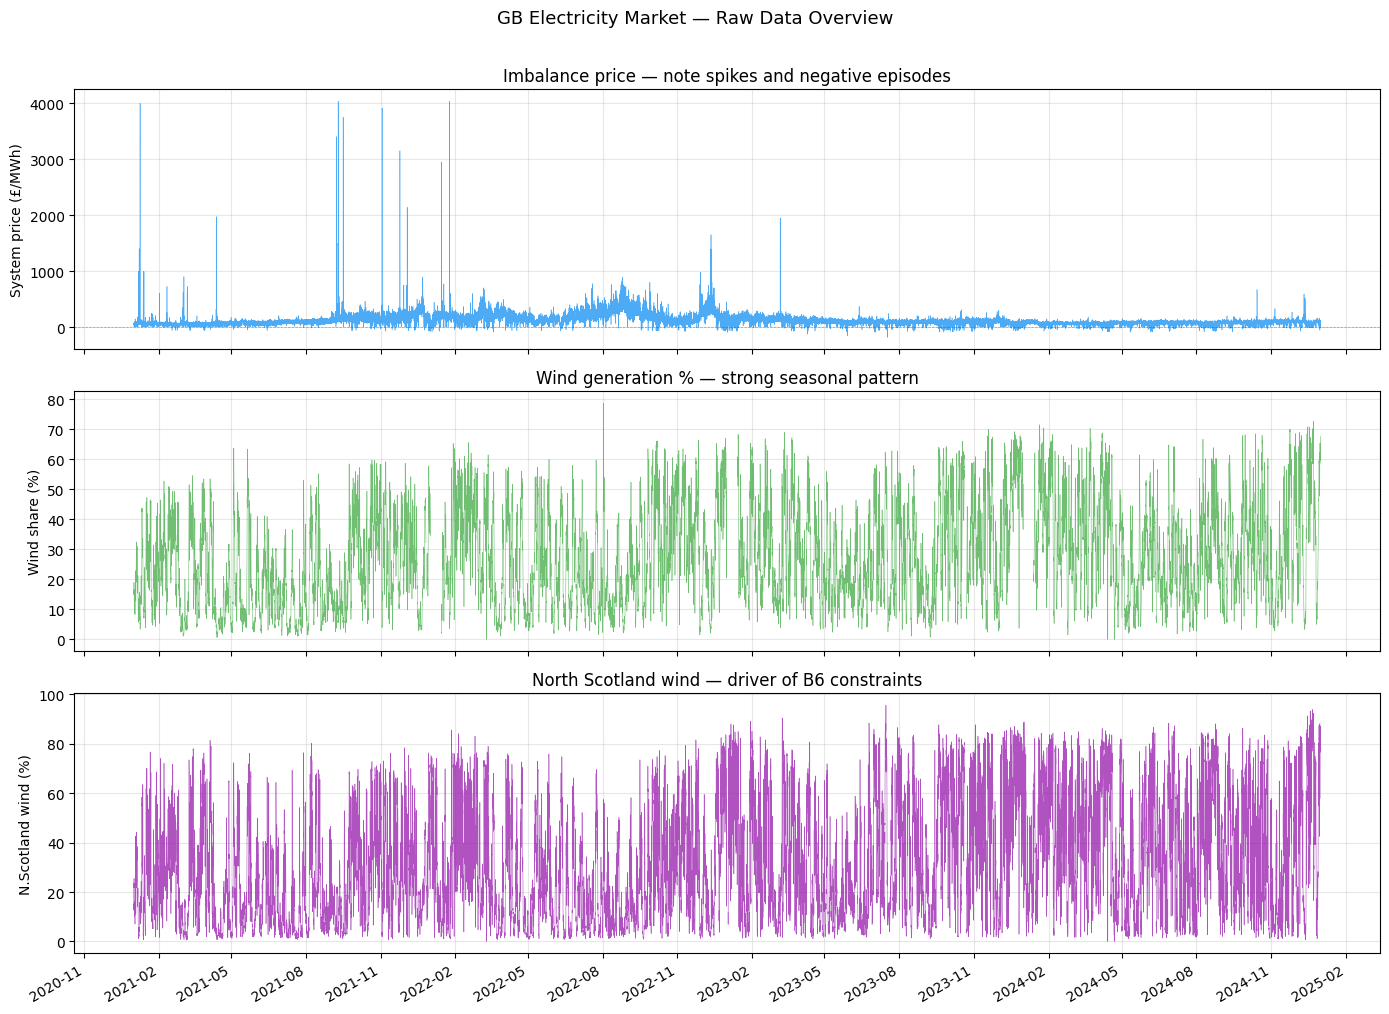

Plot saved to data/01_raw_data_overview.png


In [66]:
# ── Quick diagnostic plot ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle("GB Electricity Market — Raw Data Overview", fontsize=13, y=1.01)

# Panel 1: System price
ax = axes[0]
ax.plot(df_master["start_time"], df_master["mid_price"], lw=0.4, color="#2196F3", alpha=0.8)
ax.axhline(0, color="red", lw=0.5, ls="--", alpha=0.5)
ax.set_ylabel("System price (£/MWh)")
ax.set_title("Imbalance price — note spikes and negative episodes")

# Panel 2: Wind generation % (if available)
ax = axes[1]
if "pct_wind" in df_master.columns:
    ax.plot(df_master["start_time"], df_master["pct_wind"], lw=0.4, color="#4CAF50", alpha=0.8)
    ax.set_ylabel("Wind share (%)")
    ax.set_title("Wind generation % — strong seasonal pattern")
elif "total_wind_mw" in df_master.columns:
    ax.plot(df_master["start_time"], df_master["total_wind_mw"], lw=0.4, color="#4CAF50", alpha=0.8)
    ax.set_ylabel("Wind (MW)")
    ax.set_title("Wind generation")

# Panel 3: Scotland wind % (if available)
ax = axes[2]
scot_wind_col = "north_scotland_pct_wind"
if scot_wind_col in df_master.columns:
    ax.plot(df_master["start_time"], df_master[scot_wind_col], lw=0.4, color="#9C27B0", alpha=0.8)
    ax.set_ylabel("N.Scotland wind (%)")
    ax.set_title("North Scotland wind — driver of B6 constraints")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.grid(True, alpha=0.3)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(DATA_DIR / "01_raw_data_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved to data/01_raw_data_overview.png")

---
## Summary

This notebook has:

1. **Pulled half-hourly GB electricity data** from two free APIs (Elexon Insights, Carbon Intensity)
   covering system prices, generation by fuel type, and Scotland-specific wind generation

2. **Cleaned and standardised** the data: UTC timestamps, numeric dtypes, parquet storage

3. **Added basic features**: Fourier seasonality, wind totals, renewable fraction

4. **Merged into a master dataset** at `data/master.parquet`

**Key observations from the quick stats**:
- Positive excess kurtosis confirms heavy tails → standard Gaussian models will underestimate risk
- Non-zero skewness (likely positive) → asymmetric return distribution
- Presence of negative prices → cannot simply take log of raw price
- These observations motivate the signature-based generative approach over classical GARCH/Heston models

**Next**: `02_eda_stylized_facts.ipynb` — systematic characterisation of the stylized facts
that our generative model must reproduce: spike statistics, seasonal ACF, vol clustering,
leverage effect, and the joint price-wind distribution.


In [49]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [70]:
# Clear widget metadata that breaks GitHub rendering
import IPython.display as display
display.clear_output()

# Strip widget state from notebook metadata
import json, os
notebook_path = "/content/drive/MyDrive/Colab Notebooks/01_data_acquisition.ipynb"  # adjust to your filename

with open(notebook_path, "r") as f:
    nb = json.load(f)

if "widgets" in nb.get("metadata", {}):
    del nb["metadata"]["widgets"]

with open(notebook_path, "w") as f:
    json.dump(nb, f, indent=1)

print("Widget metadata cleared")

Widget metadata cleared


In [73]:
import json

notebook_path = "/content/drive/MyDrive/Colab Notebooks/01_data_acquisition.ipynb"

with open(notebook_path, "r") as f:
    nb = json.load(f)

# Strip widget metadata from top-level notebook metadata
nb["metadata"].pop("widgets", None)

# Strip all output and metadata from every cell
for cell in nb["cells"]:
    cell["outputs"] = []
    cell["execution_count"] = None
    cell.get("metadata", {}).pop("widgets", None)

with open(notebook_path, "w") as f:
    json.dump(nb, f, indent=1)

print("Stripped successfully")

Stripped successfully
